# 🚗 Notebook 1: YOLO11 License Plate Detector Training
## Indonesian ALPR Pipeline — Stage 1: Plate Detection

---

### 📋 Deskripsi
Notebook ini merupakan **tahap pertama** dari pipeline ALPR (Automatic License Plate Recognition) untuk plat nomor Indonesia.

**Tugas YOLO pada notebook ini:**
> *"Di gambar ini, plat nomor berada di koordinat mana?"*

YOLO hanya bertugas menemukan **lokasi (bounding box)** plat, bukan membaca teksnya.

### 🗂️ Dataset yang Digunakan
| Dataset | Sumber | Jumlah Gambar | Format Anotasi |
|:--------|:-------|:-------------:|:--------------:|
| Indonesian License Plate Dataset | Kaggle (juanthomaswijaya) | 1.000 | YOLO TXT |
| Indonesian Vehicle License Plate Detection | Kaggle (M Razif Rizqullah) | 1.377 | COCO JSON |
| **Total** | | **~2.377** | **YOLO TXT** |

### 🔬 Eksperimen
| Eksperimen | Model | Augmentasi | Target |
|:-----------|:------|:----------:|:------:|
| Exp-A | YOLO11n (nano) | Standard | Baseline cepat |
| Exp-B | YOLO11s (small) | Standard | Baseline akurasi |
| **Exp-C** | **YOLO11s (small)** | **Enhanced (+LP-aware)** | **Recommended** |
| Exp-D | YOLO11m (medium) | Enhanced | Research/Advanced |

### ⚙️ Environment
- **Platform**: Kaggle Notebooks
- **GPU**: NVIDIA Tesla T4 × 2 (Multi-GPU)
- **RAM**: ~13 GB per GPU
- **Framework**: Ultralytics YOLO11 (PyTorch backend)

### 📤 Output Notebook Ini
- `best.pt` — model weights terbaik YOLO Plate Detector
- `last.pt` — model weights epoch terakhir
- Laporan metrik: Precision, Recall, mAP@50, mAP@50:95
- Grafik training & validation loss


---
## 🔧 Bagian 0: Verifikasi GPU & Environment

In [1]:
# ============================================================
# Cell 0.1 — Download Dataset ANPR.zip dari Google Drive & Unzip
# ============================================================
# File ANPR.zip berisi dua folder utama:
#   1. Indonesian Plate Dataset/
#   2. Indonesian Vehicle Liscense Plate Dataset/
#
# PANDUAN PENGGUNAAN:
# 1. Upload file ANPR.zip ke Google Drive Anda.
# 2. Share file: Anyone with the link (Viewer).
# 3. Salin file ID dari link Drive (antara /d/ dan /view):
#    Contoh: https://drive.google.com/file/d/1aFSf47bcI-5spmxrpZgW2poUf2MbKf0i/view
#    Maka GDRIVE_FILE_ID = "1aFSf47bcI-5spmxrpZgW2poUf2MbKf0i"

GDRIVE_FILE_ID = "12_V2N723jaXhnBhmL_v5IgnYKsvHETLT"

import os
from pathlib import Path

WORKING_DIR = Path("/kaggle/working")
ZIP_PATH    = WORKING_DIR / "ANPR.zip"
EXTRACT_DIR = WORKING_DIR / "ANPR"

# Cek apakah dataset sudah tersedia
already_extracted = EXTRACT_DIR.exists() and any(EXTRACT_DIR.iterdir())

if not already_extracted:
    if GDRIVE_FILE_ID != "YOUR_GDRIVE_FILE_ID_HERE":
        print("=" * 60)
        print("🚀 PROSES DOWNLOAD & EXTRAKSI DATASET ANPR.zip")
        print("=" * 60)
        
        # 1. Install gdown
        !pip install gdown -q
        import gdown
        
        # 2. Download zip dari Google Drive
        if not ZIP_PATH.exists():
            print(f"⬇️ Mengunduh ANPR.zip dari Google Drive (ID: {GDRIVE_FILE_ID})...")
            download_url = f"https://drive.google.com/uc?id={GDRIVE_FILE_ID}"
            gdown.download(download_url, str(ZIP_PATH), quiet=False)
        
        # 3. Unzip ke /kaggle/working/ANPR
        if ZIP_PATH.exists() and ZIP_PATH.stat().st_size > 1000:
            print(f"📦 Mengekstrak ANPR.zip ke {EXTRACT_DIR} ...")
            EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
            !unzip -q "{ZIP_PATH}" -d "{EXTRACT_DIR}"
            
            # 4. Hapus zip sementara untuk menghemat kuota disk Kaggle
            try:
                ZIP_PATH.unlink()
                print("🧹 File ANPR.zip sementara dihapus untuk menghemat ruang disk.")
            except Exception as e:
                print(f"⚠️ Gagal menghapus zip sementara: {e}")
            print("✅ Ekstraksi selesai! Folder ANPR siap digunakan.")
        else:
            print("⚠️ File ANPR.zip tidak ditemukan atau ukuran tidak valid.")
            print("   Pastikan file ID Drive benar dan share link diset 'Anyone with the link'!")
    else:
        print("ℹ️ GDRIVE_FILE_ID masih bernilai default ('YOUR_GDRIVE_FILE_ID_HERE').")
        print("   Lewati cell ini jika dataset sudah di-attach via /kaggle/input/ atau lokal.")
else:
    print(f"✅ Dataset ANPR sudah tersedia di: {EXTRACT_DIR}")


🚀 PROSES DOWNLOAD & EXTRAKSI DATASET ANPR.zip
⬇️ Mengunduh ANPR.zip dari Google Drive (ID: 12_V2N723jaXhnBhmL_v5IgnYKsvHETLT)...


Downloading...
From (original): https://drive.google.com/uc?id=12_V2N723jaXhnBhmL_v5IgnYKsvHETLT
From (redirected): https://drive.google.com/uc?id=12_V2N723jaXhnBhmL_v5IgnYKsvHETLT&confirm=t&uuid=2cb3e44e-5df3-4ee0-ac7d-5f3641ee0858
To: /kaggle/working/ANPR.zip
100%|██████████| 3.52G/3.52G [01:17<00:00, 45.3MB/s]

📦 Mengekstrak ANPR.zip ke /kaggle/working/ANPR ...


🧹 File ANPR.zip sementara dihapus untuk menghemat ruang disk.
✅ Ekstraksi selesai! Folder ANPR siap digunakan.


In [2]:
# ============================================================
# Cell 0.1 — Verifikasi GPU Kaggle T4x2
# ============================================================
import subprocess
import torch
import os

print("=" * 60)
print("GPU & CUDA ENVIRONMENT VERIFICATION")
print("=" * 60)

# PyTorch & CUDA info
print(f"PyTorch Version      : {torch.__version__}")
print(f"CUDA Available       : {torch.cuda.is_available()}")
print(f"CUDA Version         : {torch.version.cuda}")
print(f"Number of GPU(s)     : {torch.cuda.device_count()}")

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"  GPU [{i}] Name      : {props.name}")
    print(f"  GPU [{i}] VRAM      : {props.total_memory / 1024**3:.1f} GB")

# Device string untuk YOLO training (gunakan semua GPU yang tersedia)
DEVICE = ','.join([str(i) for i in range(torch.cuda.device_count())]) if torch.cuda.is_available() else 'cpu'
print(f"\nDevice string YOLO   : '{DEVICE}'")

# CPU info
import multiprocessing
print(f"CPU Cores (Workers)  : {multiprocessing.cpu_count()}")
NUM_WORKERS = min(8, multiprocessing.cpu_count())
print(f"Num Workers (capped) : {NUM_WORKERS}")

print("=" * 60)
print("✅ Environment verified. Ready to proceed.")

GPU & CUDA ENVIRONMENT VERIFICATION
PyTorch Version      : 2.10.0+cu128
CUDA Available       : True
CUDA Version         : 12.8
Number of GPU(s)     : 2
  GPU [0] Name      : Tesla T4
  GPU [0] VRAM      : 14.6 GB
  GPU [1] Name      : Tesla T4
  GPU [1] VRAM      : 14.6 GB

Device string YOLO   : '0,1'
CPU Cores (Workers)  : 4
Num Workers (capped) : 4
✅ Environment verified. Ready to proceed.


In [3]:
# ============================================================
# Cell 0.2 — Install & Update Library
# ============================================================
# Kaggle sudah menyertakan banyak library, tapi kita pastikan
# versi ultralytics yang digunakan adalah yang terbaru.

!pip install ultralytics -q

import ultralytics
print(f"Ultralytics version  : {ultralytics.__version__}")
ultralytics.checks()  # Verifikasi setup Ultralytics lengkap

Ultralytics 8.4.144 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Setup complete ✅ (4 CPUs, 31.3 GB RAM, 7035.6/8062.4 GB disk)


---
## 📦 Bagian 1: Konfigurasi Path & Konstanta

In [4]:
# ============================================================
# Cell 1.1 — Konfigurasi Path Dataset (Smart Path Discovery)
# ============================================================
# Sistem otomatis mencari subfolder dataset baik dari hasil unzip Drive
# (/kaggle/working/ANPR) maupun dari Kaggle Input (/kaggle/input/...) atau lokal.
#
# Subfolder yang dibutuhkan untuk YOLO Deteksi:
#   1. Indonesian License Plate Dataset (format YOLO: images/ & labels/)
#   2. plate_detection_dataset (format COCO: images/ & annotations/annotations.json)

import os
from pathlib import Path

# ─── Search Roots ─────────────────────────────────────────────────────────────
KAGGLE_INPUT   = Path("/kaggle/input")
KAGGLE_WORKING = Path("/kaggle/working")

SEARCH_ROOTS = [
    KAGGLE_WORKING / "ANPR",
    KAGGLE_WORKING,
    KAGGLE_INPUT / "anpr",
    KAGGLE_INPUT,
    Path("d:/Deteksi Plat"),
]

def find_yolo_detection_paths(roots):
    ds1_root = None
    ds2_images = None
    ds2_annot = None
    
    for r in roots:
        if not r.exists():
            continue
            
        # Cari DS1 (YOLO format: folder memiliki subfolder 'images/train' dan 'labels/train')
        if ds1_root is None:
            for p in r.rglob("Indonesian License Plate Dataset"):
                if (p / "images" / "train").exists() and (p / "labels" / "train").exists():
                    ds1_root = p
                    break
            if ds1_root is None:
                for p in r.rglob("labels"):
                    if (p / "train").exists() and (p.parent / "images" / "train").exists() and "Recognition" not in str(p.parent):
                        ds1_root = p.parent
                        break
                        
        # Cari DS2 (COCO format: memiliki annotations.json dan folder images)
        if ds2_annot is None:
            for p in r.rglob("annotations.json"):
                ds2_annot = p
                for cand in [p.parent.parent / "images", p.parent / "images"]:
                    if cand.exists():
                        ds2_images = cand
                        break
                break
                
        if ds1_root is not None and ds2_annot is not None and ds2_images is not None:
            break
            
    return ds1_root, ds2_images, ds2_annot

DS1_ROOT, DS2_IMAGES, DS2_ANNOT = find_yolo_detection_paths(SEARCH_ROOTS)
DS2_ROOT = DS2_ANNOT.parent.parent if DS2_ANNOT else None

# ─── Output Directory ──────────────────────────────────────────────────────────
WORK_DIR   = KAGGLE_WORKING / "yolo_plate_detector"
MERGED_DIR = WORK_DIR / "merged_dataset"  # Dataset gabungan setelah preprocessing

# Buat direktori output
for split in ["train", "val", "test"]:
    (MERGED_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (MERGED_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print(f"Work Directory   : {WORK_DIR}")
print(f"Merged Dataset   : {MERGED_DIR}")
print()

# Verifikasi keberadaan dataset
print("=" * 65)
print("Dataset Path Verification (YOLO Plate Detector)")
print("=" * 65)
items = [
    (DS1_ROOT,   "DS1 Root (Indonesian License Plate Dataset)"),
    (DS2_ROOT,   "DS2 Root (plate_detection_dataset)"),
    (DS2_IMAGES, "DS2 Images Directory"),
    (DS2_ANNOT,  "DS2 Annotations (annotations.json)"),
]

all_found = True
for path, label in items:
    found = path is not None and path.exists()
    status = "✅" if found else "❌ NOT FOUND"
    print(f"{status} {label:<45}: {path if found else 'Tidak ditemukan'}")
    if not found:
        all_found = False

print("=" * 65)
if all_found:
    print("🎉 Seluruh komponen dataset deteksi berhasil ditemukan & tersinkronisasi!")
else:
    print("⚠️ Ada komponen yang belum ditemukan. Periksa apakah ANPR.zip sudah diekstrak.")


Work Directory   : /kaggle/working/yolo_plate_detector
Merged Dataset   : /kaggle/working/yolo_plate_detector/merged_dataset

Dataset Path Verification (YOLO Plate Detector)
✅ DS1 Root (Indonesian License Plate Dataset)  : /kaggle/working/ANPR/Indonesian Plate Dataset/Indonesian License Plate Dataset
✅ DS2 Root (plate_detection_dataset)           : /kaggle/working/ANPR/Indonesian Vehicle Liscense Plate Dataset/plate_detection_dataset/plate_detection_dataset
✅ DS2 Images Directory                         : /kaggle/working/ANPR/Indonesian Vehicle Liscense Plate Dataset/plate_detection_dataset/plate_detection_dataset/images
✅ DS2 Annotations (annotations.json)           : /kaggle/working/ANPR/Indonesian Vehicle Liscense Plate Dataset/plate_detection_dataset/plate_detection_dataset/annotations/annotations.json
🎉 Seluruh komponen dataset deteksi berhasil ditemukan & tersinkronisasi!


In [5]:
# ============================================================
# Cell 1.2 — Konstanta Global Eksperimen
# ============================================================

# ─── Split Ratio (dari SPLIT_DETECTION.md) ─────────────────────────────────────
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.20
TEST_RATIO  = 0.10

# ─── Dataset Config ─────────────────────────────────────────────────────────────
IMG_SIZE    = 640
CLASS_NAMES = ["license_plate"]
NUM_CLASSES = 1
RANDOM_SEED = 42

# ─── Training Config ────────────────────────────────────────────────────────────
# Batch 32 per GPU → effective batch 64 dengan T4x2 (DDP)
BATCH_SIZE      = 32
EPOCHS_BASELINE = 50
EPOCHS_FULL     = 100
PATIENCE        = 20

# ─── Pretrained Weights (Transfer Learning dari COCO) ─────────────────────────
MODEL_CONFIGS = {
    "Exp-A": "yolo11n.pt",  # Nano  (~2.6M params) — Baseline tercepat
    "Exp-B": "yolo11s.pt",  # Small (~9.4M params) — Balance speed/accuracy
    "Exp-C": "yolo11s.pt",  # Small + augmentasi enhanced (RECOMMENDED)
    "Exp-D": "yolo11m.pt",  # Medium (~20M params) — Advanced/Research
}

print("=" * 55)
print("GLOBAL CONSTANTS CONFIGURED")
print("=" * 55)
print(f"Split Ratio      : Train={TRAIN_RATIO} | Val={VAL_RATIO} | Test={TEST_RATIO}")
print(f"Image Size       : {IMG_SIZE}px")
print(f"Classes          : {CLASS_NAMES}")
print(f"Batch Size       : {BATCH_SIZE} per GPU → Effective: {BATCH_SIZE * max(1, torch.cuda.device_count())}")
print(f"Epochs (Baseline): {EPOCHS_BASELINE}")
print(f"Epochs (Full)    : {EPOCHS_FULL}")
print(f"Early Stopping   : Patience={PATIENCE}")
print(f"Random Seed      : {RANDOM_SEED}")
print()
print("Experiment Models:")
for k, v in MODEL_CONFIGS.items():
    print(f"  {k}: {v}")

GLOBAL CONSTANTS CONFIGURED
Split Ratio      : Train=0.7 | Val=0.2 | Test=0.1
Image Size       : 640px
Classes          : ['license_plate']
Batch Size       : 32 per GPU → Effective: 64
Epochs (Baseline): 50
Epochs (Full)    : 100
Early Stopping   : Patience=20
Random Seed      : 42

Experiment Models:
  Exp-A: yolo11n.pt
  Exp-B: yolo11s.pt
  Exp-C: yolo11s.pt
  Exp-D: yolo11m.pt


---
## 📊 Bagian 2: Persiapan Dataset

### Alur:
```
Dataset 1 (YOLO TXT)  ──────────────────────────────────────────┐
                                                                 ├─→ MERGED DATASET (YOLO TXT) → split 70:20:10
Dataset 2 (COCO JSON) ── [konversi COCO→YOLO] ─→ YOLO TXT ─────┘
```

In [6]:
# ============================================================
# Cell 2.1 — Fungsi Konversi COCO JSON → YOLO TXT
# ============================================================
import json
import shutil
from pathlib import Path

def coco_to_yolo_bbox(bbox, img_width, img_height):
    """
    Konversi format COCO bbox [x_min, y_min, width, height]
    → format YOLO [x_center, y_center, width, height] (ternormalisasi 0–1)
    """
    x_min, y_min, w, h = bbox
    x_center = (x_min + w / 2) / img_width
    y_center = (y_min + h / 2) / img_height
    w_norm   = w / img_width
    h_norm   = h / img_height
    # Clamp ke [0, 1]
    x_center = max(0.0, min(1.0, x_center))
    y_center = max(0.0, min(1.0, y_center))
    w_norm   = max(0.0, min(1.0, w_norm))
    h_norm   = max(0.0, min(1.0, h_norm))
    return x_center, y_center, w_norm, h_norm


def convert_coco_to_yolo(coco_json_path, images_src_dir, output_dir):
    """
    Konversi seluruh dataset dari format COCO JSON ke format YOLO TXT.
    Gambar di-copy ke output_dir/images/, label ditulis ke output_dir/labels/

    Catatan Dataset 2:
      - 1 kategori: 'plate_number' → class_id = 0
      - Satu gambar bisa memiliki lebih dari 1 anotasi plat
    """
    output_dir = Path(output_dir)
    img_out_dir = output_dir / "images"
    lbl_out_dir = output_dir / "labels"
    img_out_dir.mkdir(parents=True, exist_ok=True)
    lbl_out_dir.mkdir(parents=True, exist_ok=True)

    with open(coco_json_path, 'r') as f:
        coco = json.load(f)

    # Mapping: image_id → info
    id_to_img = {img['id']: img for img in coco['images']}

    # Mapping: image_id → list annotations
    id_to_anns = {}
    for ann in coco['annotations']:
        id_to_anns.setdefault(ann['image_id'], []).append(ann)

    converted, skipped = 0, 0

    for img_id, img_info in id_to_img.items():
        fname = img_info['file_name']
        src   = Path(images_src_dir) / fname

        if not src.exists():
            skipped += 1
            continue

        img_w = int(img_info['width'])
        img_h = int(img_info['height'])

        # Prefix 'ds2_' agar tidak ada konflik nama dengan Dataset 1
        stem_new = f"ds2_{Path(fname).stem}"
        ext      = Path(fname).suffix
        dst_img  = img_out_dir / f"{stem_new}{ext}"
        dst_lbl  = lbl_out_dir / f"{stem_new}.txt"

        shutil.copy2(src, dst_img)

        annotations = id_to_anns.get(img_id, [])
        with open(dst_lbl, 'w') as f_lbl:
            for ann in annotations:
                if ann.get('iscrowd', 0) == 1:
                    continue
                xc, yc, wn, hn = coco_to_yolo_bbox(ann['bbox'], img_w, img_h)
                f_lbl.write(f"0 {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}\n")

        converted += 1

    return converted, skipped


print("✅ Fungsi konversi COCO → YOLO siap digunakan.")

✅ Fungsi konversi COCO → YOLO siap digunakan.


In [7]:
# ============================================================
# Cell 2.2 — Konversi Dataset 2 (COCO JSON → YOLO TXT)
# ============================================================
import time

DS2_CONVERTED_DIR = WORK_DIR / "ds2_converted"

print("[Dataset 2] Memulai konversi COCO JSON → YOLO TXT...")
t0 = time.time()

converted, skipped = convert_coco_to_yolo(
    coco_json_path = DS2_ANNOT,
    images_src_dir = DS2_IMAGES,
    output_dir     = DS2_CONVERTED_DIR
)

elapsed = time.time() - t0
print(f"✅ Konversi selesai dalam {elapsed:.1f} detik")
print(f"   Gambar berhasil dikonversi : {converted}")
print(f"   Gambar dilewati (not found): {skipped}")

# Verifikasi beberapa file label hasil konversi
print("\nSample Label DS2 (verifikasi format YOLO):")
sample_labels = list((DS2_CONVERTED_DIR / "labels").glob("*.txt"))[:3]
for lbl in sample_labels:
    print(f"  [{lbl.name}]")
    with open(lbl) as f:
        for line in f:
            print(f"    {line.strip()}")

[Dataset 2] Memulai konversi COCO JSON → YOLO TXT...
✅ Konversi selesai dalam 0.5 detik
   Gambar berhasil dikonversi : 1374
   Gambar dilewati (not found): 3

Sample Label DS2 (verifikasi format YOLO):
  [ds2_train183_jpg.rf.a993786df17f12004ba4792d9446c03b.txt]
    0 0.440625 0.780469 0.211719 0.058594
  [ds2_H4157K_jpg.rf.412e4adc2b62d451c446643535b6d186.txt]
    0 0.525000 0.342187 0.792188 0.282813
  [ds2_train219_jpg.rf.1714148fb284849e59688c48c2574a0b.txt]
    0 0.240625 0.668750 0.085938 0.021094


In [8]:
# ============================================================
# Cell 2.3 — Penggabungan & Re-split Dataset (70:20:10)
#
# Strategi:
#   Dataset 1 sudah memiliki split sendiri → kumpulkan semua,
#   lalu re-split bersama Dataset 2 secara seragam.
#
# Anti data-leakage:
#   Shuffle berdasarkan seed tetap agar reproducible.
# ============================================================
import random

random.seed(RANDOM_SEED)


def collect_ds1(ds1_root: Path):
    """Kumpulkan pasangan (img_path, lbl_path) dari Dataset 1 (semua split)."""
    pairs = []
    # Dataset 1 ada di dalam subfolder 'Indonesian License Plate Dataset'
    base = (
        ds1_root
        if (ds1_root / "images").exists()
        else (ds1_root / "Indonesian License Plate Dataset")
    )

    for split in ["train", "val", "test"]:
        img_dir = base / "images" / split
        lbl_dir = base / "labels" / split
        if not img_dir.exists():
            continue
        for img_path in sorted(img_dir.glob("*.jpg")):
            lbl_path = lbl_dir / f"{img_path.stem}.txt"
            if lbl_path.exists():
                pairs.append((img_path, lbl_path))
    return pairs


def collect_ds2_converted(ds2_converted_dir: Path):
    """Kumpulkan pasangan (img_path, lbl_path) dari hasil konversi Dataset 2."""
    pairs = []
    img_dir = ds2_converted_dir / "images"
    lbl_dir = ds2_converted_dir / "labels"
    for img_path in sorted(img_dir.glob("*.*")):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if lbl_path.exists():
            pairs.append((img_path, lbl_path))
    return pairs


pairs_ds1 = collect_ds1(DS1_ROOT)
pairs_ds2 = collect_ds2_converted(DS2_CONVERTED_DIR)
all_pairs  = pairs_ds1 + pairs_ds2

print(f"Gambar dari Dataset 1 : {len(pairs_ds1)}")
print(f"Gambar dari Dataset 2 : {len(pairs_ds2)}")
print(f"Total gabungan        : {len(all_pairs)}")

random.shuffle(all_pairs)

n_total = len(all_pairs)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

split_data = {
    "train": all_pairs[:n_train],
    "val"  : all_pairs[n_train:n_train + n_val],
    "test" : all_pairs[n_train + n_val:],
}

print(f"\nDistribusi Split:")
print(f"  Train : {len(split_data['train'])} ({len(split_data['train'])/n_total*100:.1f}%)")
print(f"  Val   : {len(split_data['val'])} ({len(split_data['val'])/n_total*100:.1f}%)")
print(f"  Test  : {len(split_data['test'])} ({len(split_data['test'])/n_total*100:.1f}%)")

Gambar dari Dataset 1 : 1000
Gambar dari Dataset 2 : 1374
Total gabungan        : 2374

Distribusi Split:
  Train : 1661 (70.0%)
  Val   : 474 (20.0%)
  Test  : 239 (10.1%)


In [9]:
# ============================================================
# Cell 2.4 — Copy File ke Struktur Direktori YOLO Final
# ============================================================

def copy_split_to_yolo_dir(split_data, merged_dir):
    """Copy gambar dan label ke struktur direktori standar YOLO."""
    for split, pairs in split_data.items():
        img_dir = merged_dir / "images" / split
        lbl_dir = merged_dir / "labels" / split
        img_dir.mkdir(parents=True, exist_ok=True)
        lbl_dir.mkdir(parents=True, exist_ok=True)

        for idx, (img_src, lbl_src) in enumerate(pairs):
            ext  = img_src.suffix.lower()
            stem = f"{split}_{idx+1:05d}"
            shutil.copy2(img_src, img_dir / f"{stem}{ext}")
            shutil.copy2(lbl_src, lbl_dir / f"{stem}.txt")


print("Menyalin file ke struktur YOLO...")
t0 = time.time()
copy_split_to_yolo_dir(split_data, MERGED_DIR)
print(f"✅ Selesai dalam {time.time() - t0:.1f} detik")

print("\nVerifikasi Jumlah File di MERGED DATASET:")
for split in ["train", "val", "test"]:
    n_img = len(list((MERGED_DIR/"images"/split).glob("*.*")))
    n_lbl = len(list((MERGED_DIR/"labels"/split).glob("*.txt")))
    match  = "✅" if n_img == n_lbl else "❌ MISMATCH"
    print(f"  {split:5s}: {n_img} images, {n_lbl} labels {match}")

Menyalin file ke struktur YOLO...
✅ Selesai dalam 1.9 detik

Verifikasi Jumlah File di MERGED DATASET:
  train: 1661 images, 1661 labels ✅
  val  : 474 images, 474 labels ✅
  test : 239 images, 239 labels ✅


In [10]:
# ============================================================
# Cell 2.5 — Buat File dataset.yaml (Konfigurasi Dataset YOLO)
# ============================================================
import yaml

dataset_yaml = {
    'path' : str(MERGED_DIR),
    'train': 'images/train',
    'val'  : 'images/val',
    'test' : 'images/test',
    'nc'   : NUM_CLASSES,
    'names': CLASS_NAMES,
}

yaml_path = MERGED_DIR / "dataset.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, sort_keys=False)

print("dataset.yaml contents:")
print("─" * 40)
with open(yaml_path) as f:
    print(f.read())
print(f"✅ Disimpan di: {yaml_path}")

dataset.yaml contents:
────────────────────────────────────────
path: /kaggle/working/yolo_plate_detector/merged_dataset
train: images/train
val: images/val
test: images/test
nc: 1
names:
- license_plate

✅ Disimpan di: /kaggle/working/yolo_plate_detector/merged_dataset/dataset.yaml


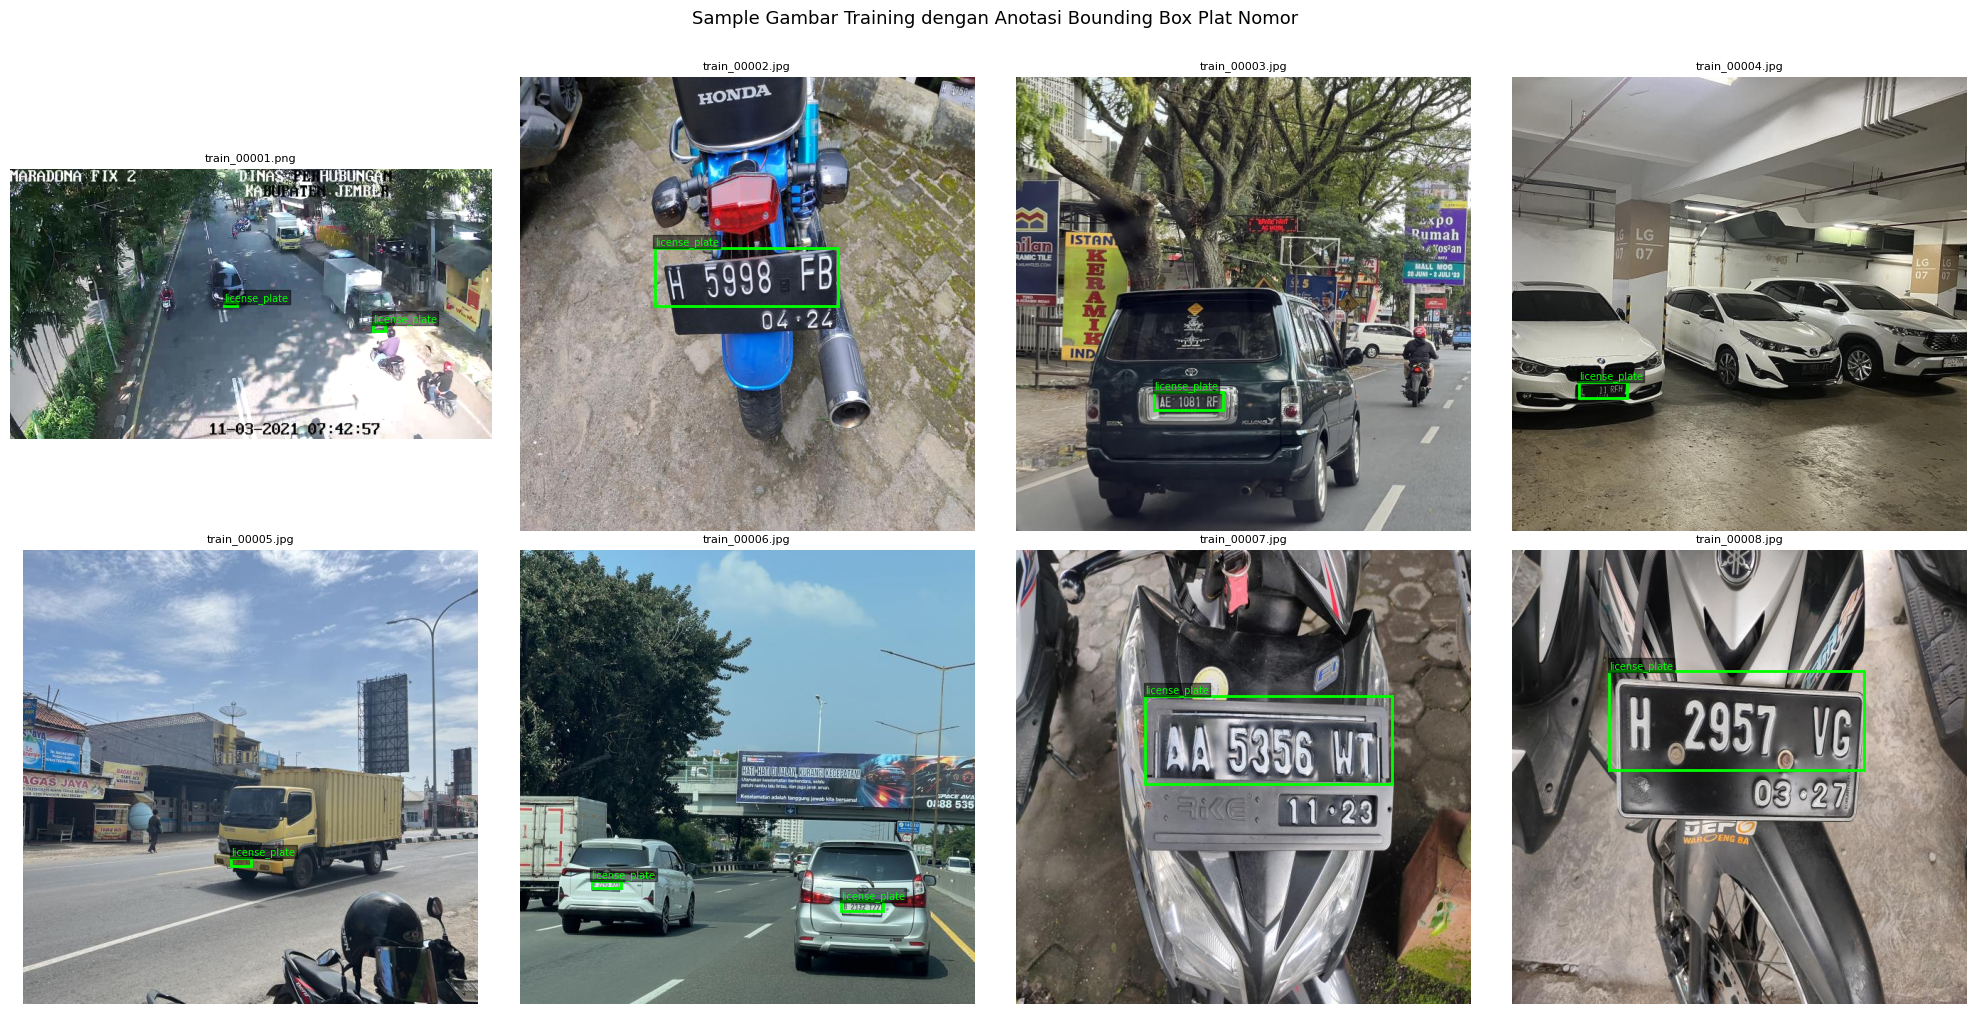

In [11]:
# ============================================================
# Cell 2.6 — EDA: Visualisasi Sampel Dataset + Bounding Box
# ============================================================
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def show_sample_with_bbox(img_dir, lbl_dir, class_names, n_samples=8, figsize=(20, 10)):
    """Tampilkan gambar sampel beserta bounding box plat nomor untuk verifikasi anotasi."""
    img_paths = sorted(list(Path(img_dir).glob("*.*")))[:n_samples]
    n_cols    = 4
    n_rows    = (n_samples + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    for i, img_path in enumerate(img_paths):
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        lbl_path = Path(lbl_dir) / f"{img_path.stem}.txt"
        axes[i].imshow(img)
        axes[i].set_title(img_path.name[:25], fontsize=8)
        axes[i].axis('off')

        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls_id = int(parts[0])
                    xc, yc, wn, hn = map(float, parts[1:5])
                    x1 = (xc - wn/2) * w
                    y1 = (yc - hn/2) * h
                    rect = patches.Rectangle(
                        (x1, y1), wn*w, hn*h,
                        linewidth=2, edgecolor='lime', facecolor='none'
                    )
                    axes[i].add_patch(rect)
                    axes[i].text(x1, y1-5, class_names[cls_id], color='lime',
                                 fontsize=7, bbox=dict(facecolor='black', alpha=0.5, pad=1))

    for j in range(len(img_paths), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Sample Gambar Training dengan Anotasi Bounding Box Plat Nomor",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


show_sample_with_bbox(
    img_dir     = MERGED_DIR / "images" / "train",
    lbl_dir     = MERGED_DIR / "labels" / "train",
    class_names = CLASS_NAMES,
    n_samples   = 8
)

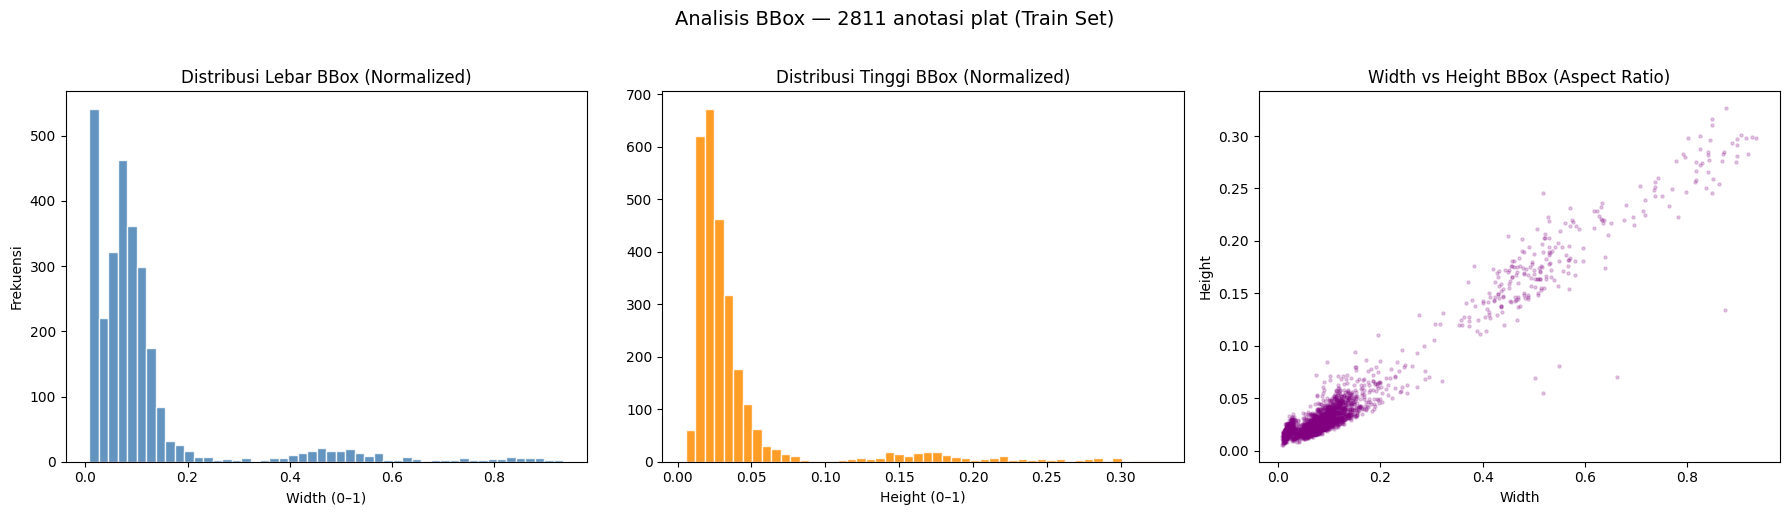

Statistik BBox (Normalized):
  Width  — Mean: 0.1163, Median: 0.0758, Std: 0.1521
  Height — Mean: 0.0414, Median: 0.0251, Std: 0.0497
  Area   — Mean: 0.012183, Min: 0.000043, Max: 0.2860


In [12]:
# ============================================================
# Cell 2.7 — EDA: Analisis Distribusi Ukuran Bounding Box
# ============================================================

def analyze_bbox_distribution(lbl_dir):
    widths, heights, areas = [], [], []
    for lbl_path in Path(lbl_dir).glob("*.txt"):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    wn = float(parts[3])
                    hn = float(parts[4])
                    widths.append(wn)
                    heights.append(hn)
                    areas.append(wn * hn)
    return widths, heights, areas


widths, heights, areas = analyze_bbox_distribution(MERGED_DIR / "labels" / "train")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(widths, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Lebar BBox (Normalized)', fontsize=12)
axes[0].set_xlabel('Width (0–1)')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(heights, bins=50, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi Tinggi BBox (Normalized)', fontsize=12)
axes[1].set_xlabel('Height (0–1)')

axes[2].scatter(widths, heights, alpha=0.2, s=5, color='purple')
axes[2].set_title('Width vs Height BBox (Aspect Ratio)', fontsize=12)
axes[2].set_xlabel('Width')
axes[2].set_ylabel('Height')

plt.suptitle(f"Analisis BBox — {len(areas)} anotasi plat (Train Set)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Statistik BBox (Normalized):")
print(f"  Width  — Mean: {np.mean(widths):.4f}, Median: {np.median(widths):.4f}, Std: {np.std(widths):.4f}")
print(f"  Height — Mean: {np.mean(heights):.4f}, Median: {np.median(heights):.4f}, Std: {np.std(heights):.4f}")
print(f"  Area   — Mean: {np.mean(areas):.6f}, Min: {np.min(areas):.6f}, Max: {np.max(areas):.4f}")

---
## 🔬 Bagian 3: Definisi Konfigurasi Eksperimen

### Desain Eksperimen:
```
Exp-A: YOLO11n + Standard Aug  → Baseline kecepatan
Exp-B: YOLO11s + Standard Aug  → Baseline akurasi
Exp-C: YOLO11s + Enhanced Aug  → RECOMMENDED (low-light & perspective aware)
Exp-D: YOLO11m + Enhanced Aug  → Research/Advanced
```

**Enhanced Augmentation** dirancang untuk kondisi nyata:
- 🌙 Pencahayaan rendah / malam (basement)
- 📐 Sudut kamera dari ketinggian (downward tilt ~20–30°)
- 📷 Blur gerak kendaraan masuk/keluar
- 🎨 Plat hitam (lama TNKB) dan plat putih (baru TNKB)

In [13]:
# ============================================================
# Cell 3.1 — Konfigurasi Augmentasi per Eksperimen
# ============================================================

# ─── Augmentasi Standard ──────────────────────────────────────────────────────
AUG_STANDARD = {
    "degrees"     : 5.0,    # Rotasi kecil
    "translate"   : 0.1,
    "scale"       : 0.5,    # Simulasi variasi jarak kendaraan
    "shear"       : 2.0,
    "perspective" : 0.0,
    "flipud"      : 0.0,    # TIDAK flip vertikal (plat tidak terbalik)
    "fliplr"      : 0.5,    # Flip horizontal boleh
    "hsv_h"       : 0.015,
    "hsv_s"       : 0.7,
    "hsv_v"       : 0.4,
    "mosaic"      : 1.0,
    "mixup"       : 0.0,
    "copy_paste"  : 0.0,
}

# ─── Augmentasi Enhanced (untuk kondisi basement & plat Indonesia) ────────────
# Mengakomodasi:
#   - Pencahayaan rendah / malam (hsv_v lebih lebar)
#   - Sudut kamera tinggi (shear & perspective lebih agresif)
#   - Blur gerak (mosaic + scale)
#   - Plat putih baru dan plat hitam lama (hsv_h & s lebih variatif)
AUG_ENHANCED = {
    "degrees"     : 10.0,   # Rotasi lebih besar (kamera miring, kendaraan belok)
    "translate"   : 0.15,
    "scale"       : 0.6,    # Variasi jarak lebih lebar
    "shear"       : 5.0,    # Simulasi perspektif kamera atas
    "perspective" : 0.001,  # Perspective transform ringan
    "flipud"      : 0.0,
    "fliplr"      : 0.5,
    "hsv_h"       : 0.015,
    "hsv_s"       : 0.7,
    "hsv_v"       : 0.6,    # Lebih lebar → simulasi low-light & over-exposure glare
    "mosaic"      : 1.0,
    "mixup"       : 0.05,
    "copy_paste"  : 0.1,
    "erasing"     : 0.3,    # Simulasi oklusi parsial (stiker, kotoran plat)
}

# ─── Definisi Eksperimen ──────────────────────────────────────────────────────
EXPERIMENTS = {
    "Exp-A": {
        "description"  : "Baseline Cepat — YOLO11n",
        "weights"      : MODEL_CONFIGS["Exp-A"],
        "epochs"       : EPOCHS_BASELINE,
        "imgsz"        : IMG_SIZE,
        "batch"        : BATCH_SIZE,
        "augmentation" : AUG_STANDARD,
        "freeze"       : 0,
        "lr0"          : 0.01,
        "lrf"          : 0.1,
        "warmup_epochs": 3.0,
        "name"         : "exp_a_yolo11n_baseline",
    },
    "Exp-B": {
        "description"  : "Baseline Akurasi — YOLO11s",
        "weights"      : MODEL_CONFIGS["Exp-B"],
        "epochs"       : EPOCHS_BASELINE,
        "imgsz"        : IMG_SIZE,
        "batch"        : BATCH_SIZE,
        "augmentation" : AUG_STANDARD,
        "freeze"       : 0,
        "lr0"          : 0.01,
        "lrf"          : 0.1,
        "warmup_epochs": 3.0,
        "name"         : "exp_b_yolo11s_baseline",
    },
    "Exp-C": {
        "description"  : "RECOMMENDED — YOLO11s + Enhanced Augmentation",
        "weights"      : MODEL_CONFIGS["Exp-C"],
        "epochs"       : EPOCHS_FULL,
        "imgsz"        : IMG_SIZE,
        "batch"        : BATCH_SIZE,
        "augmentation" : AUG_ENHANCED,
        "freeze"       : 0,
        "lr0"          : 0.01,
        "lrf"          : 0.01,   # LR decay lebih dalam
        "warmup_epochs": 5.0,
        "name"         : "exp_c_yolo11s_enhanced",
    },
    "Exp-D": {
        "description"  : "Research/Advanced — YOLO11m + Enhanced Augmentation",
        "weights"      : MODEL_CONFIGS["Exp-D"],
        "epochs"       : EPOCHS_FULL,
        "imgsz"        : IMG_SIZE,
        "batch"        : 16,      # Batch lebih kecil untuk model yang lebih besar
        "augmentation" : AUG_ENHANCED,
        "freeze"       : 10,      # Freeze 10 layer backbone untuk efisiensi
        "lr0"          : 0.005,   # LR lebih kecil untuk model besar
        "lrf"          : 0.01,
        "warmup_epochs": 5.0,
        "name"         : "exp_d_yolo11m_advanced",
    },
}

print("=" * 60)
print("KONFIGURASI EKSPERIMEN")
print("=" * 60)
for exp_id, cfg in EXPERIMENTS.items():
    print(f"\n[{exp_id}] {cfg['description']}")
    print(f"  Weights  : {cfg['weights']}")
    print(f"  Epochs   : {cfg['epochs']}")
    print(f"  Batch    : {cfg['batch']}")
    print(f"  Freeze   : {cfg['freeze']} layers")
    print(f"  LR Range : {cfg['lr0']} → {cfg['lr0']*cfg['lrf']:.5f}")

KONFIGURASI EKSPERIMEN

[Exp-A] Baseline Cepat — YOLO11n
  Weights  : yolo11n.pt
  Epochs   : 50
  Batch    : 32
  Freeze   : 0 layers
  LR Range : 0.01 → 0.00100

[Exp-B] Baseline Akurasi — YOLO11s
  Weights  : yolo11s.pt
  Epochs   : 50
  Batch    : 32
  Freeze   : 0 layers
  LR Range : 0.01 → 0.00100

[Exp-C] RECOMMENDED — YOLO11s + Enhanced Augmentation
  Weights  : yolo11s.pt
  Epochs   : 100
  Batch    : 32
  Freeze   : 0 layers
  LR Range : 0.01 → 0.00010

[Exp-D] Research/Advanced — YOLO11m + Enhanced Augmentation
  Weights  : yolo11m.pt
  Epochs   : 100
  Batch    : 16
  Freeze   : 10 layers
  LR Range : 0.005 → 0.00005


---
## 🚀 Bagian 4: Training YOLO11 (Transfer Learning)

### Strategi Fine-Tuning:
```
YOLO11*.pt  (pretrained COCO 80 classes)
      │
      │  Transfer Learning
      ▼
Fine-tune untuk 'license_plate' (1 class)
```
Detection head di-reset oleh Ultralytics (80 → 1 class),  
backbone tetap memanfaatkan fitur visual umum yang sudah dipelajari.

In [14]:
# ============================================================
# Cell 4.1 — Fungsi Training Satu Eksperimen
# ============================================================
from ultralytics import YOLO
import gc

def train_experiment(exp_id, exp_cfg, yaml_path, device_str, output_dir):
    """
    Melatih satu eksperimen YOLO dengan transfer learning dari pretrained COCO weights.

    Args:
        exp_id      : ID eksperimen (misal 'Exp-C')
        exp_cfg     : Dict konfigurasi eksperimen
        yaml_path   : Path ke file dataset.yaml
        device_str  : String GPU ('0,1' untuk T4x2)
        output_dir  : Direktori penyimpanan hasil training

    Returns:
        best_model_path (Path), results object
    """
    print("\n" + "═" * 65)
    print(f"  TRAINING: [{exp_id}] {exp_cfg['description']}")
    print("═" * 65)
    print(f"  Weights  : {exp_cfg['weights']}")
    print(f"  Epochs   : {exp_cfg['epochs']}")
    print(f"  Device   : {device_str}")
    print(f"  Freeze   : {exp_cfg['freeze']} layers")
    print("═" * 65)

    # Load pretrained YOLO weights (otomatis unduh dari Ultralytics jika belum ada)
    model = YOLO(exp_cfg['weights'])

    train_args = {
        # ─── Core ──────────────────────────────────────────────────────────
        "data"           : str(yaml_path),
        "epochs"         : exp_cfg['epochs'],
        "imgsz"          : exp_cfg['imgsz'],
        "batch"          : exp_cfg['batch'],
        "device"         : device_str,
        "project"        : str(output_dir),
        "name"           : exp_cfg['name'],
        "exist_ok"       : True,

        # ─── Optimizer & LR Schedule ───────────────────────────────────────
        "optimizer"      : "AdamW",       # Stabil untuk fine-tuning
        "lr0"            : exp_cfg['lr0'],
        "lrf"            : exp_cfg['lrf'],
        "momentum"       : 0.937,
        "weight_decay"   : 0.0005,
        "warmup_epochs"  : exp_cfg['warmup_epochs'],
        "warmup_momentum": 0.8,
        "warmup_bias_lr" : 0.1,

        # ─── Loss Weights ──────────────────────────────────────────────────
        "box"            : 7.5,
        "cls"            : 0.5,
        "dfl"            : 1.5,

        # ─── Training Strategy ─────────────────────────────────────────────
        "freeze"         : exp_cfg['freeze'],
        "patience"       : PATIENCE,        # Early stopping
        "save"           : True,
        "save_period"    : -1,              # Hanya simpan best & last
        "plots"          : True,
        "verbose"        : True,
        "seed"           : RANDOM_SEED,
        "workers"        : NUM_WORKERS,

        # ─── Mixed Precision (AMP) ─────────────────────────────────────────
        # AMP mempercepat training di T4 yang mendukung Tensor Cores
        "amp"            : True,

        # ─── Augmentasi ────────────────────────────────────────────────────
        **exp_cfg['augmentation'],
    }

    results = model.train(**train_args)

    best_path = Path(output_dir) / exp_cfg['name'] / "weights" / "best.pt"

    print(f"\n✅ Training [{exp_id}] selesai!")
    print(f"   Best model: {best_path}")

    # Bersihkan GPU memory sebelum eksperimen berikutnya
    del model
    gc.collect()
    torch.cuda.empty_cache()

    return best_path, results


print("✅ Fungsi training siap digunakan.")

✅ Fungsi training siap digunakan.


In [15]:
# ============================================================
# Cell 4.2 — PILIH EKSPERIMEN YANG AKAN DIJALANKAN
#
# ⚠️  REKOMENDASI PENGGUNAAN KUOTA GPU KAGGLE (30 jam/minggu):
#
#   Sesi 1: ["Exp-A", "Exp-B"] → dapatkan angka baseline (~2–3 jam)
#   Sesi 2: ["Exp-C"]          → model RECOMMENDED (~2–3 jam)
#   Sesi 3: ["Exp-D"]          → advanced/research (~3–4 jam)
#
#   Ubah list di bawah sesuai sesi saat ini:
# ============================================================

EXPERIMENTS_TO_RUN = ["Exp-A", "Exp-B"]  # ← UBAH SESUAI KEBUTUHAN

RESULTS_DIR = WORK_DIR / "training_results"
RESULTS_DIR.mkdir(exist_ok=True)

print("Eksperimen yang akan dijalankan sesi ini:")
for exp_id in EXPERIMENTS_TO_RUN:
    cfg = EXPERIMENTS[exp_id]
    n_train_imgs = len(list((MERGED_DIR/"images"/"train").glob("*.*")))
    # Estimasi kasar: ~500 img/menit di T4x2
    est_min = (cfg['epochs'] * n_train_imgs / 500) / 2
    print(f"  [{exp_id}] {cfg['description']} — estimasi ~{est_min:.0f} menit")

Eksperimen yang akan dijalankan sesi ini:
  [Exp-A] Baseline Cepat — YOLO11n — estimasi ~83 menit
  [Exp-B] Baseline Akurasi — YOLO11s — estimasi ~83 menit


In [16]:
# ============================================================
# Cell 4.3 — EKSEKUSI TRAINING
#
# Progress bar dan metrik per epoch akan tampil di bawah cell ini.
# Pastikan Kaggle session TIDAK dibiarkan idle > 1 jam saat training.
# ============================================================

exp_results = {}
best_models = {}

for exp_id in EXPERIMENTS_TO_RUN:
    exp_cfg = EXPERIMENTS[exp_id]

    try:
        best_path, results = train_experiment(
            exp_id     = exp_id,
            exp_cfg    = exp_cfg,
            yaml_path  = yaml_path,
            device_str = DEVICE,
            output_dir = RESULTS_DIR,
        )
        best_models[exp_id] = best_path
        exp_results[exp_id] = results

    except Exception as e:
        print(f"\n❌ Training [{exp_id}] gagal: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "═" * 50)
print("SEMUA TRAINING SELESAI")
print("═" * 50)
for exp_id, path in best_models.items():
    status = "✅" if path.exists() else "❌ Missing"
    print(f"  {status} [{exp_id}] Best model: {path}")


═════════════════════════════════════════════════════════════════
  TRAINING: [Exp-A] Baseline Cepat — YOLO11n
═════════════════════════════════════════════════════════════════
  Weights  : yolo11n.pt
  Epochs   : 50
  Device   : 0,1
  Freeze   : 0 layers
═════════════════════════════════════════════════════════════════
Ultralytics 8.4.144 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_plate_detector/merged_dataset/dataset.yaml, degrees=5.0, deterministic=True, device=0,1, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      2.95G      1.961      1.619      1.331         27        640: 100% ━━━━━━━━━━━━ 52/52 1.5it/s 35.4s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.1s/it 9.1s1.0s
                   all        474        808   0.000437     0.0767    3.3e-05   1.15e-05

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      2.95G      1.894      1.493      1.319         24        640: 100% ━━━━━━━━━━━━ 52/52 1.7it/s 31.3s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.0it/s 7.8s0.8s
                   all        474        808     0.0192     0.0507    0.00707    0.00233

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      2.95G      1.881       1.42      1.231         59        640: 100%

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      5.06G      2.048      1.689      1.437         27        640: 100% ━━━━━━━━━━━━ 52/52 1.5it/s 34.3s0.6ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.0s/it 8.2s0.8s
                   all        474        808          0          0          0          0

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      5.06G      1.977       1.58      1.426         24        640: 100% ━━━━━━━━━━━━ 52/52 1.5it/s 35.0s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.0s/it 8.2s0.7s
                   all        474        808     0.0116    0.00124   8.77e-05   6.08e-05

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/50      5.06G      1.948      1.501       1.32         59        640: 100%

---
## 📈 Bagian 5: Evaluasi & Perbandingan Hasil

In [17]:
# ============================================================
# Cell 5.1 — Evaluasi pada Test Set per Eksperimen
# ============================================================

evaluation_summary = {}  # {exp_id: {metric_name: value}}

for exp_id, best_path in best_models.items():
    if not best_path.exists():
        print(f"⚠️ [{exp_id}] Lewati — model tidak ditemukan.")
        continue

    print(f"\n[{exp_id}] Mengevaluasi pada Test Set...")
    model = YOLO(str(best_path))

    metrics = model.val(
        data    = str(yaml_path),
        split   = "test",
        imgsz   = IMG_SIZE,
        batch   = BATCH_SIZE,
        device  = DEVICE,
        verbose = True,
    )

    evaluation_summary[exp_id] = {
        "Precision" : round(float(metrics.box.mp),    4),
        "Recall"    : round(float(metrics.box.mr),    4),
        "mAP@50"    : round(float(metrics.box.map50), 4),
        "mAP@50:95" : round(float(metrics.box.map),   4),
    }

    del model
    gc.collect()
    torch.cuda.empty_cache()

print("\nEvaluasi selesai.")


[Exp-A] Mengevaluasi pada Test Set...
Ultralytics 8.4.144 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                        CUDA:1 (Tesla T4, 14912MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2940.7±1286.6 MB/s, size: 1264.7 KB)
val: Scanning /kaggle/working/yolo_plate_detector/merged_dataset/labels/test... 239 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 239/239 773.3it/s 0.3s0.2s
val: New cache created: /kaggle/working/yolo_plate_detector/merged_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.2it/s 6.5s0.5ss
                   all        239        409      0.875      0.844      0.915      0.561
Speed: 1.9ms preprocess, 4.6ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

[Exp-B] Mengeval

In [18]:
# ============================================================
# Cell 5.2 — Tabel Perbandingan Metrik
# ============================================================
import pandas as pd

summary_rows = []
for exp_id, metrics in evaluation_summary.items():
    cfg = EXPERIMENTS[exp_id]
    row = {
        "Eksperimen" : exp_id,
        "Model"      : cfg['weights'],
        "Epochs"     : cfg['epochs'],
        "Augmentasi" : "Enhanced" if cfg['augmentation'] is AUG_ENHANCED else "Standard",
        **metrics,
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

print("=" * 85)
print("TABEL PERBANDINGAN HASIL EKSPERIMEN — TEST SET")
print("=" * 85)
print(df_summary.to_string(index=False))

csv_path = WORK_DIR / "experiment_comparison.csv"
df_summary.to_csv(csv_path, index=False)
print(f"\n✅ Disimpan ke: {csv_path}")

if len(df_summary) > 0 and "mAP@50" in df_summary.columns:
    best_row = df_summary.loc[df_summary["mAP@50"].idxmax()]
    print(f"\n🏆 Model Terbaik (mAP@50): [{best_row['Eksperimen']}] {EXPERIMENTS[best_row['Eksperimen']]['description']}")
    print(f"   mAP@50   : {best_row['mAP@50']}")
    print(f"   mAP@50:95: {best_row['mAP@50:95']}")
    print(f"   Precision: {best_row['Precision']}")
    print(f"   Recall   : {best_row['Recall']}")

TABEL PERBANDINGAN HASIL EKSPERIMEN — TEST SET
Eksperimen      Model  Epochs Augmentasi  Precision  Recall  mAP@50  mAP@50:95
     Exp-A yolo11n.pt      50   Standard     0.8755  0.8435  0.9153     0.5606
     Exp-B yolo11s.pt      50   Standard     0.8293  0.9022  0.9174     0.5472

✅ Disimpan ke: /kaggle/working/yolo_plate_detector/experiment_comparison.csv

🏆 Model Terbaik (mAP@50): [Exp-B] Baseline Akurasi — YOLO11s
   mAP@50   : 0.9174
   mAP@50:95: 0.5472
   Precision: 0.8293
   Recall   : 0.9022


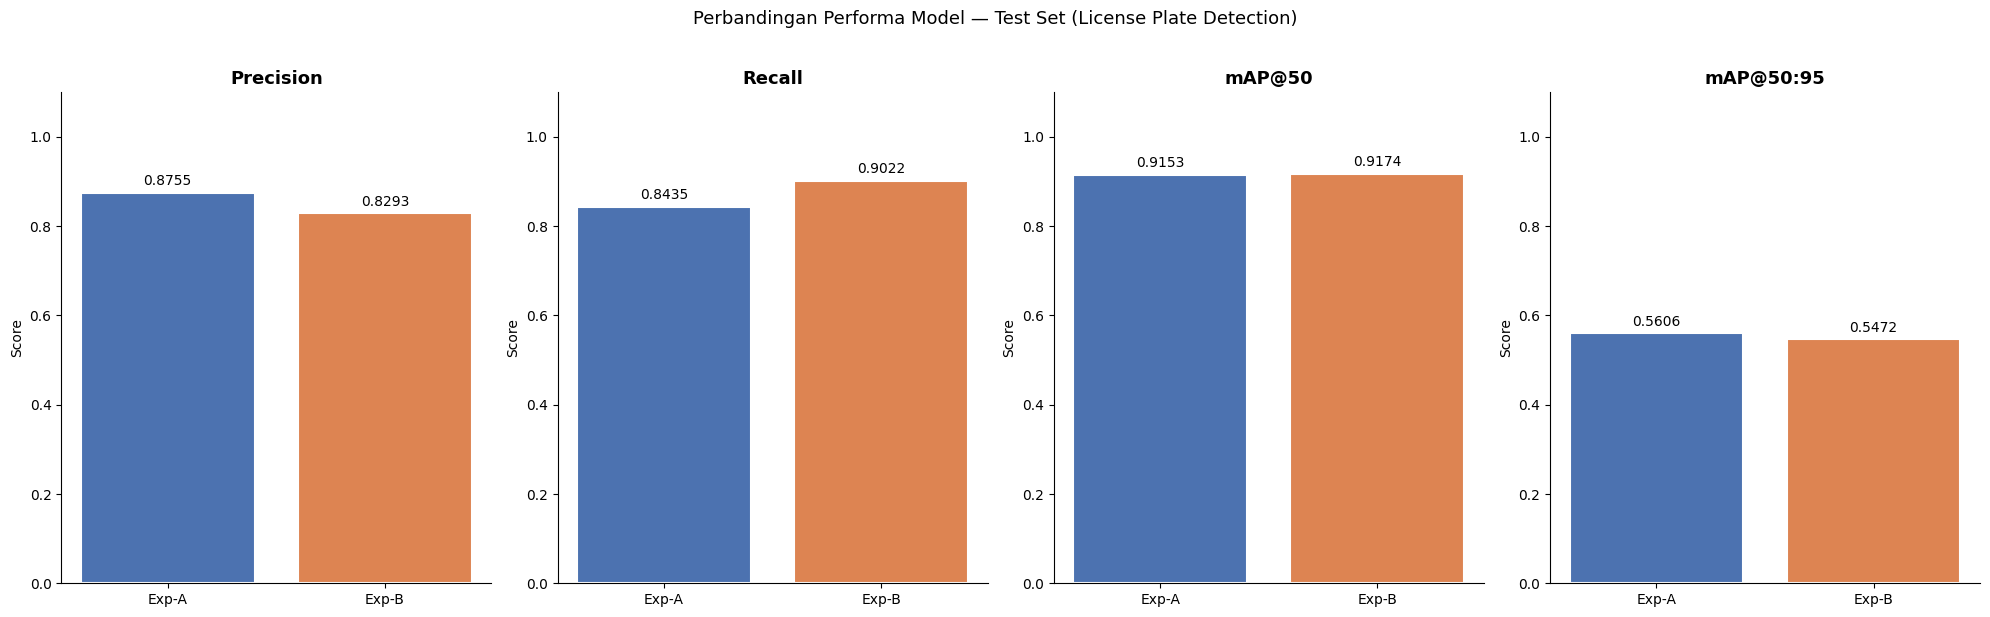

✅ Plot disimpan.


In [19]:
# ============================================================
# Cell 5.3 — Visualisasi Perbandingan Metrik (Bar Chart)
# ============================================================

if len(df_summary) > 1:
    metric_cols = ["Precision", "Recall", "mAP@50", "mAP@50:95"]
    available   = [m for m in metric_cols if m in df_summary.columns]

    fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 6))
    if len(available) == 1:
        axes = [axes]

    colors     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
    exp_labels = df_summary['Eksperimen'].tolist()

    for i, metric in enumerate(available):
        values = df_summary[metric].tolist()
        bars   = axes[i].bar(exp_labels, values,
                             color=colors[:len(exp_labels)],
                             edgecolor='white', linewidth=1.5)
        axes[i].set_title(metric, fontsize=13, fontweight='bold')
        axes[i].set_ylim(0, 1.1)
        axes[i].set_ylabel('Score')
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        for bar in bars:
            h = bar.get_height()
            axes[i].text(bar.get_x() + bar.get_width()/2., h + 0.01,
                         f'{h:.4f}', ha='center', va='bottom', fontsize=10)

    plt.suptitle('Perbandingan Performa Model — Test Set (License Plate Detection)',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(WORK_DIR / "metrics_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Plot disimpan.")

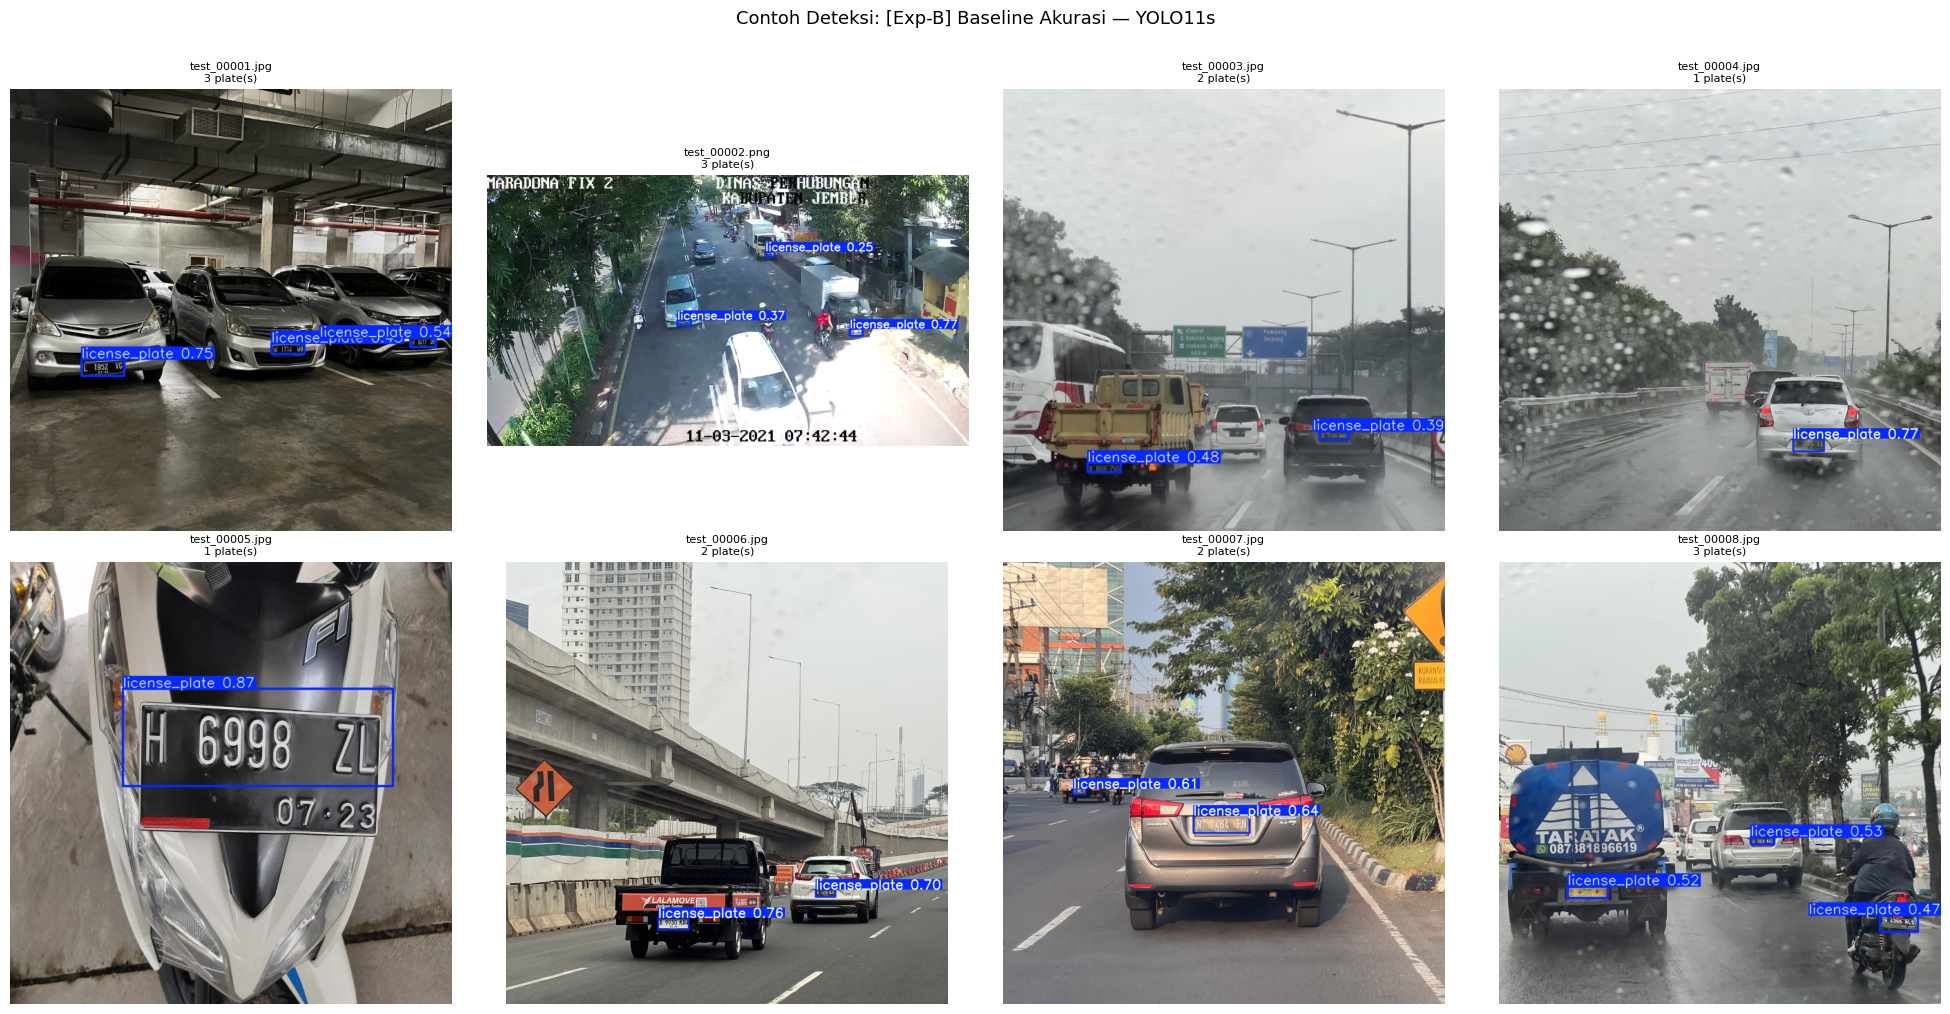

In [20]:
# ============================================================
# Cell 5.4 — Visualisasi Contoh Deteksi (Inference Samples)
# ============================================================

if best_models and len(df_summary) > 0 and "mAP@50" in df_summary.columns:
    best_exp_id   = df_summary.loc[df_summary["mAP@50"].idxmax()]["Eksperimen"]
    best_wts_path = best_models.get(best_exp_id)

    if best_wts_path and best_wts_path.exists():
        model_best  = YOLO(str(best_wts_path))
        test_images = sorted(list((MERGED_DIR/"images"/"test").glob("*.*")))[:8]

        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.flatten()

        for i, img_path in enumerate(test_images):
            results_inf = model_best(
                source  = str(img_path),
                conf    = 0.25,
                iou     = 0.45,
                imgsz   = IMG_SIZE,
                verbose = False,
            )
            annotated = results_inf[0].plot()
            annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
            n_det     = len(results_inf[0].boxes)
            axes[i].imshow(annotated)
            axes[i].set_title(f"{img_path.name[:22]}\n{n_det} plate(s)", fontsize=8)
            axes[i].axis('off')

        plt.suptitle(f"Contoh Deteksi: [{best_exp_id}] {EXPERIMENTS[best_exp_id]['description']}",
                     fontsize=13, y=1.01)
        plt.tight_layout()
        plt.savefig(WORK_DIR / "inference_samples.png", dpi=150, bbox_inches='tight')
        plt.show()

        del model_best
        gc.collect()
        torch.cuda.empty_cache()

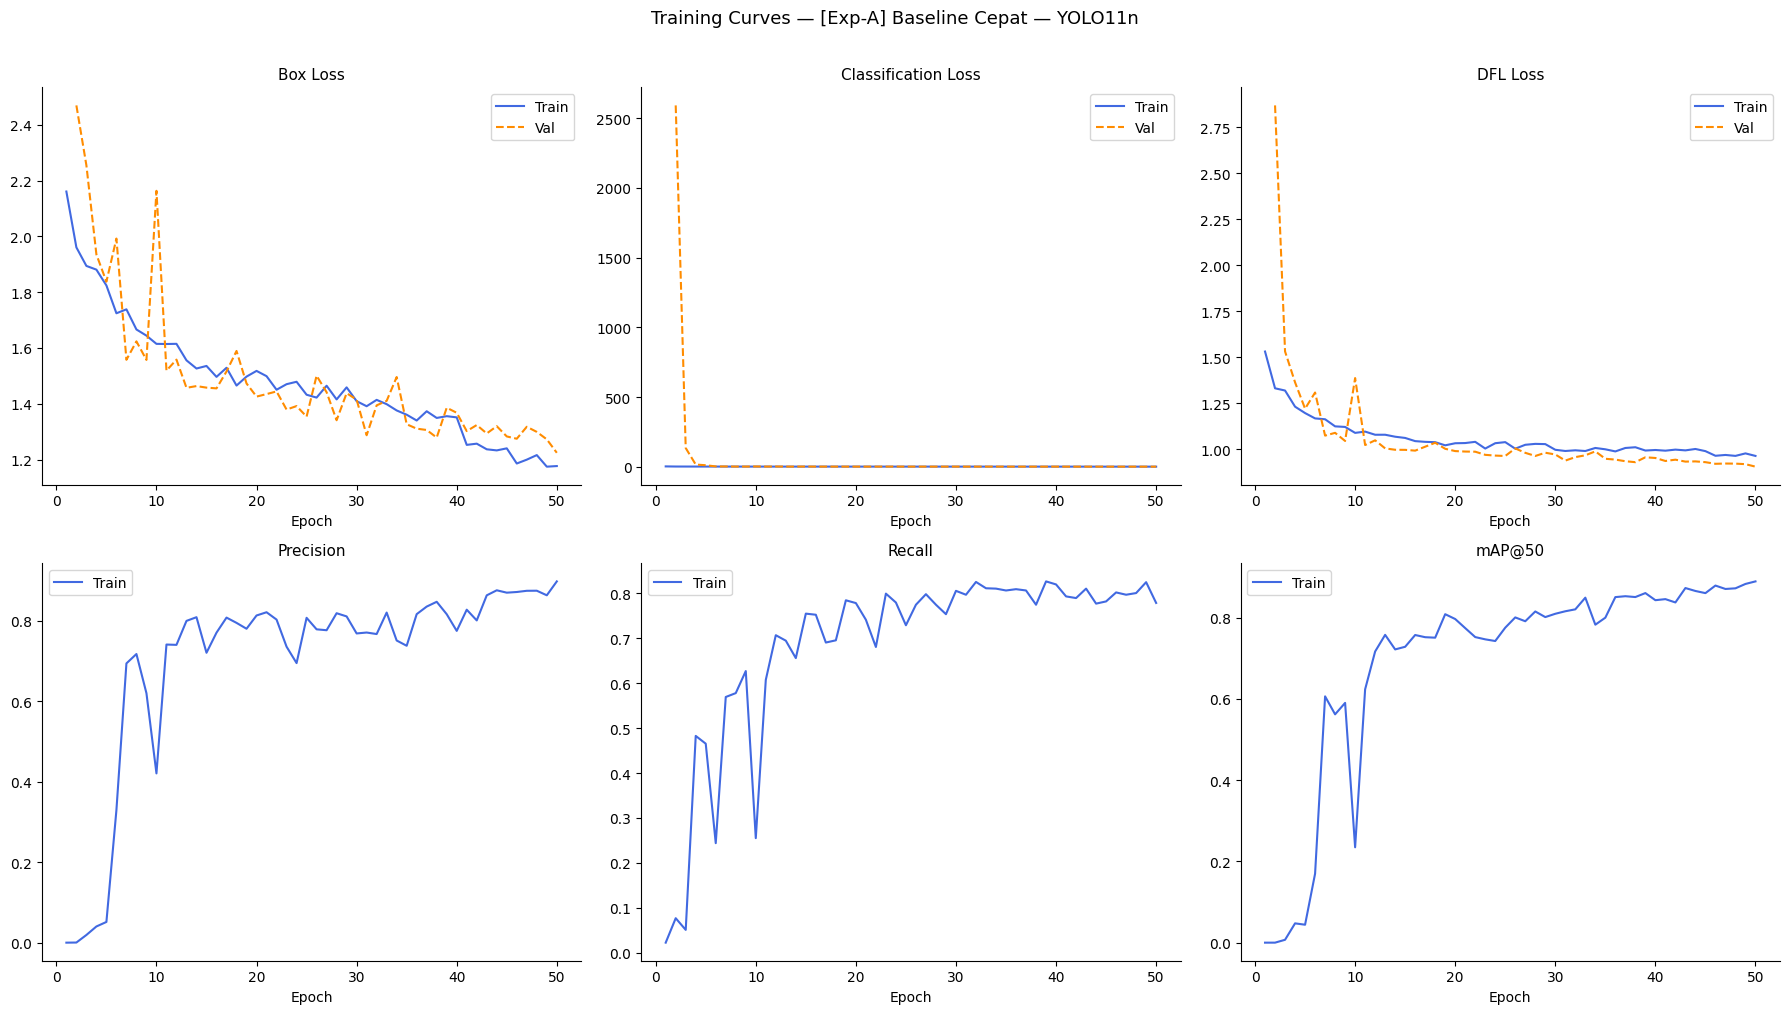

✅ [Exp-A] Training curve disimpan: /kaggle/working/yolo_plate_detector/training_curve_exp_a.png


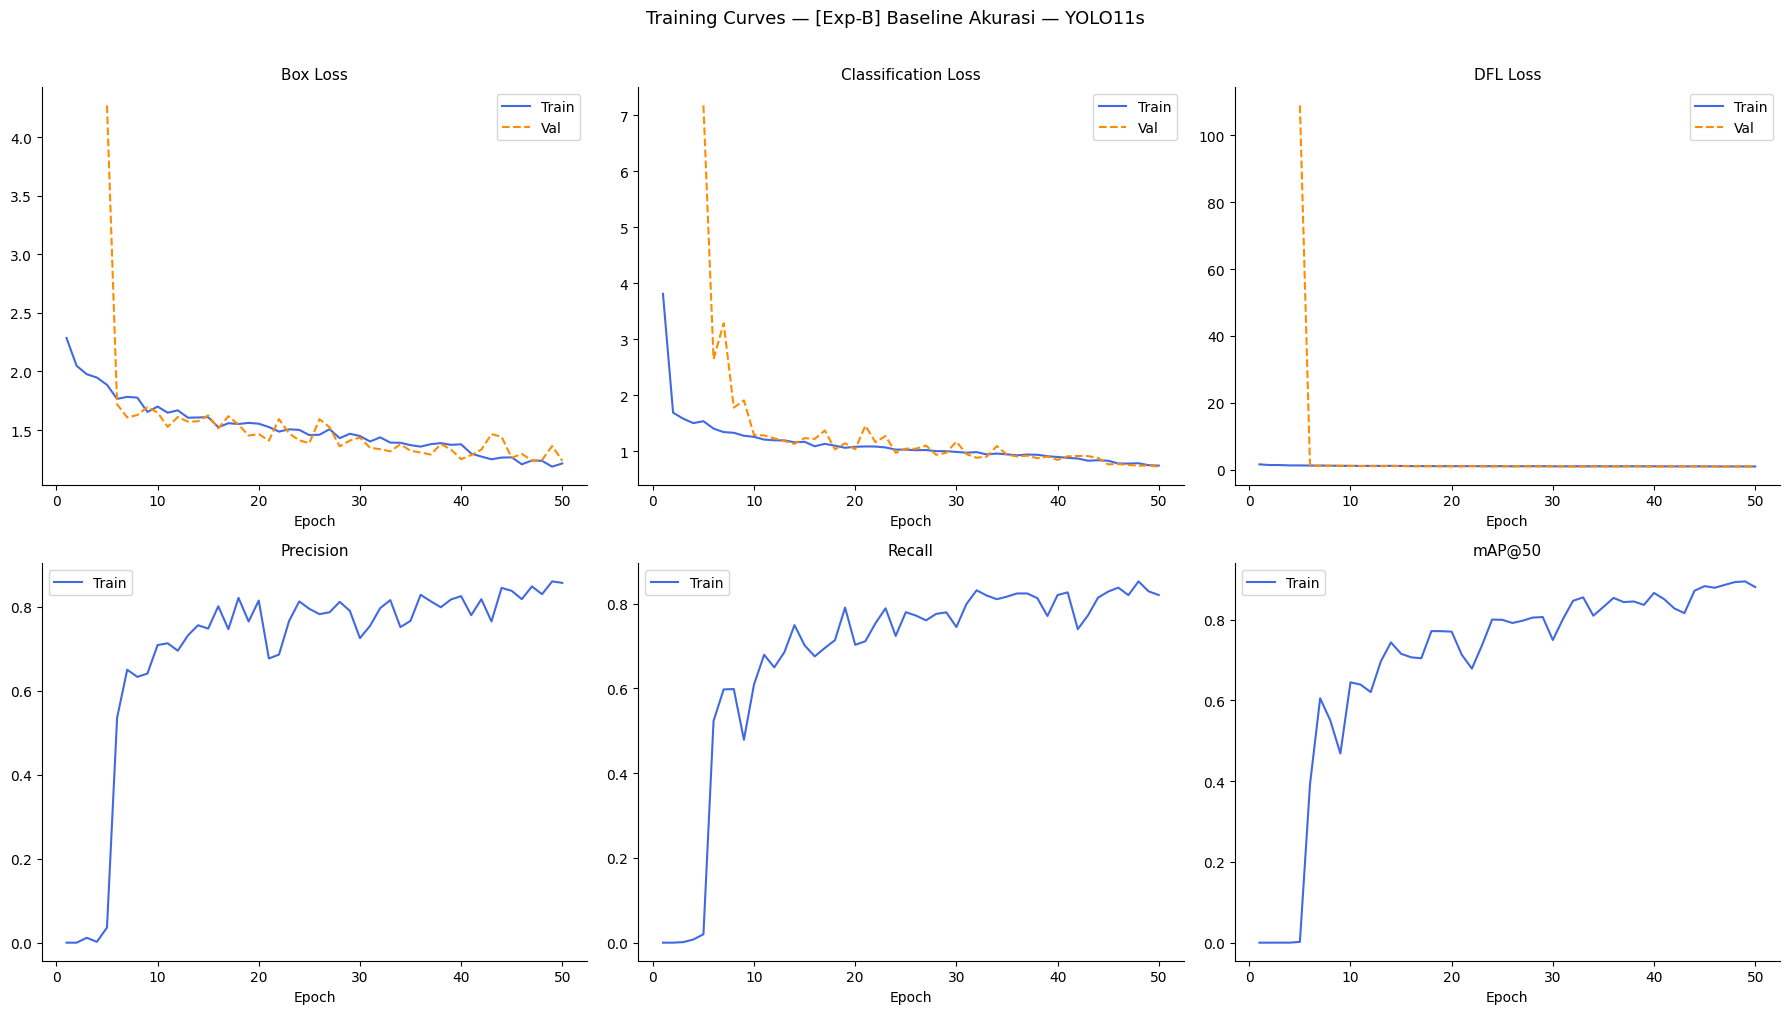

✅ [Exp-B] Training curve disimpan: /kaggle/working/yolo_plate_detector/training_curve_exp_b.png


In [21]:
# ============================================================
# Cell 5.5 — Training Curves per Eksperimen
# ============================================================

for exp_id in EXPERIMENTS_TO_RUN:
    exp_name   = EXPERIMENTS[exp_id]['name']
    result_csv = RESULTS_DIR / exp_name / "results.csv"

    if not result_csv.exists():
        print(f"⚠️ [{exp_id}] results.csv tidak ditemukan.")
        continue

    df_res = pd.read_csv(result_csv)
    df_res.columns = df_res.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Training Curves — [{exp_id}] {EXPERIMENTS[exp_id]['description']}",
                 fontsize=13, y=1.01)

    plot_config = [
        ('train/box_loss',         'val/box_loss',        'Box Loss'),
        ('train/cls_loss',         'val/cls_loss',        'Classification Loss'),
        ('train/dfl_loss',         'val/dfl_loss',        'DFL Loss'),
        ('metrics/precision(B)',   None,                  'Precision'),
        ('metrics/recall(B)',      None,                  'Recall'),
        ('metrics/mAP50(B)',       None,                  'mAP@50'),
    ]

    axes_flat = axes.flatten()
    epochs    = df_res.get('epoch', range(len(df_res)))

    for ax, (col_tr, col_val, title) in zip(axes_flat, plot_config):
        if col_tr in df_res.columns:
            ax.plot(epochs, df_res[col_tr], label='Train', color='royalblue')
        if col_val and col_val in df_res.columns:
            ax.plot(epochs, df_res[col_val], label='Val', color='darkorange', linestyle='--')
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    curve_path = WORK_DIR / f"training_curve_{exp_id.lower().replace('-', '_')}.png"
    plt.savefig(curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ [{exp_id}] Training curve disimpan: {curve_path}")

---
## 💾 Bagian 6: Simpan Model & Ringkasan Akhir

In [22]:
# ============================================================
# Cell 6.1 — Copy Model Terbaik ke /kaggle/working/final_models/
#
# File di /kaggle/working/ akan tersimpan sebagai output notebook
# dan bisa dijadikan dataset input untuk Notebook 2 & 3.
# ============================================================
import json

final_output_dir = KAGGLE_WORKING / "final_models"
final_output_dir.mkdir(exist_ok=True)

final_model_registry = {}

for exp_id, best_path in best_models.items():
    if best_path.exists():
        dest_name = f"yolo_plate_{exp_id.lower().replace('-', '_')}_best.pt"
        dest_path = final_output_dir / dest_name
        shutil.copy2(best_path, dest_path)
        final_model_registry[exp_id] = {
            "filename"   : dest_name,
            "description": EXPERIMENTS[exp_id]['description'],
            "metrics"    : evaluation_summary.get(exp_id, {}),
        }
        print(f"✅ [{exp_id}] → {dest_path}")
    else:
        print(f"⚠️ [{exp_id}] Best model tidak ada, skip.")

# Simpan registry ke JSON
registry_path = final_output_dir / "model_registry.json"
with open(registry_path, 'w') as f:
    json.dump(final_model_registry, f, indent=2)

print(f"\n✅ Registry disimpan: {registry_path}")
print("\nSemua file di final_models/:")
for f in sorted(final_output_dir.glob("*.*")):
    size_mb = f.stat().st_size / 1024**2
    print(f"  {f.name} ({size_mb:.1f} MB)")

✅ [Exp-A] → /kaggle/working/final_models/yolo_plate_exp_a_best.pt
✅ [Exp-B] → /kaggle/working/final_models/yolo_plate_exp_b_best.pt

✅ Registry disimpan: /kaggle/working/final_models/model_registry.json

Semua file di final_models/:
  model_registry.json (0.0 MB)
  yolo_plate_exp_a_best.pt (5.2 MB)
  yolo_plate_exp_b_best.pt (18.3 MB)


In [23]:
# ============================================================
# Cell 6.2 — Ringkasan Akhir Notebook 1
# ============================================================

print("\n" + "═" * 70)
print("  📋 RINGKASAN AKHIR — NOTEBOOK 1: YOLO PLATE DETECTOR")
print("═" * 70)

n_train = len(list((MERGED_DIR/"images"/"train").glob("*.*")))
n_val   = len(list((MERGED_DIR/"images"/"val").glob("*.*")))
n_test  = len(list((MERGED_DIR/"images"/"test").glob("*.*")))
n_total = n_train + n_val + n_test

print(f"\n📦 DATASET YANG DIGUNAKAN:")
print(f"   Total gambar : {n_total}")
print(f"   Train        : {n_train} ({n_train/n_total*100:.1f}%)")
print(f"   Val          : {n_val}   ({n_val/n_total*100:.1f}%)")
print(f"   Test         : {n_test}  ({n_test/n_total*100:.1f}%)")
print(f"   Kelas        : {CLASS_NAMES}")

print(f"\n🔬 HASIL EKSPERIMEN:")
for exp_id in EXPERIMENTS_TO_RUN:
    m = evaluation_summary.get(exp_id, {})
    print(f"   [{exp_id}] {EXPERIMENTS[exp_id]['description']}")
    if m:
        print(f"     Precision: {m.get('Precision','N/A')} | "
              f"Recall: {m.get('Recall','N/A')} | "
              f"mAP@50: {m.get('mAP@50','N/A')} | "
              f"mAP@50:95: {m.get('mAP@50:95','N/A')}")

print(f"\n💾 FILE OUTPUT (di /kaggle/working/final_models/):")
for f in sorted(final_output_dir.glob("*.*")):
    size_mb = f.stat().st_size / 1024**2
    print(f"   {f.name} ({size_mb:.1f} MB)")

print(f"\n🔗 LANGKAH BERIKUTNYA:")
print(f"   Notebook 2: Fine-tuning OCR Recognizer (TrOCR / PaddleOCR)")
print(f"     → Input  : plate_text_dataset (1.863 crop plat + label.csv)")
print(f"     → Output : best_ocr.pth / checkpoint TrOCR")
print(f"   Notebook 3: Master Pipeline End-to-End (YOLO → OpenCV → OCR → Regex)")
print(f"     → Input  : best_yolo.pt (dari NB1) + best_ocr.pth (dari NB2)")
print(f"     → Output : Evaluasi lengkap (mAP + CER + Exact Match) + Demo")

print("\n" + "═" * 70)
print("  ✅ NOTEBOOK 1 SELESAI")
print("═" * 70)


══════════════════════════════════════════════════════════════════════
  📋 RINGKASAN AKHIR — NOTEBOOK 1: YOLO PLATE DETECTOR
══════════════════════════════════════════════════════════════════════

📦 DATASET YANG DIGUNAKAN:
   Total gambar : 2374
   Train        : 1661 (70.0%)
   Val          : 474   (20.0%)
   Test         : 239  (10.1%)
   Kelas        : ['license_plate']

🔬 HASIL EKSPERIMEN:
   [Exp-A] Baseline Cepat — YOLO11n
     Precision: 0.8755 | Recall: 0.8435 | mAP@50: 0.9153 | mAP@50:95: 0.5606
   [Exp-B] Baseline Akurasi — YOLO11s
     Precision: 0.8293 | Recall: 0.9022 | mAP@50: 0.9174 | mAP@50:95: 0.5472

💾 FILE OUTPUT (di /kaggle/working/final_models/):
   model_registry.json (0.0 MB)
   yolo_plate_exp_a_best.pt (5.2 MB)
   yolo_plate_exp_b_best.pt (18.3 MB)

🔗 LANGKAH BERIKUTNYA:
   Notebook 2: Fine-tuning OCR Recognizer (TrOCR / PaddleOCR)
     → Input  : plate_text_dataset (1.863 crop plat + label.csv)
     → Output : best_ocr.pth / checkpoint TrOCR
   Notebook 3: Mas